In [7]:
# -*- coding: utf-8 -*-
"""
无/有向图链接预测评测（按“阈值曲线下的面积”定义）
- 正样本：test_edges
- 负样本（无向）：由 train 节点诱导完全图，去除 train_edges 与 test_edges（无向、无自环）
- 负样本（有向）：由 train 节点诱导有向完全图（u!=v 的有序对），去除 train_edges 与 test_edges（有向、无自环）
- 每个算法需提供：name 属性 与 score_pairs(edge_index) 方法，返回 [0,1] 分数
- 对每个阈值 θ∈[0,1] 计算：
    TP/|P|, FN/|P|, FP/|N|, TN/|N|
  并对四条曲线各自积分（阈值为横轴，比例为纵轴），得到 AUC
"""

from dataclasses import dataclass
from typing import Iterable, List, Tuple, Dict, Sequence, Optional
import numpy as np
from tqdm.notebook import tqdm

Edge = Tuple[int, int]  # 注意：有向模式下表示有序对 (u, v)；无向模式下表示规范化后 (min, max)

# -----------------------------
# 无向工具（保持原语义，未改）
# -----------------------------
def _canon_edge_undirected(u: int, v: int) -> Edge:
    if u == v:
        raise ValueError("自环不允许作为边。")
    return (u, v) if u < v else (v, u)

def canon_edges_undirected(edges: Iterable[Tuple[int, int]]) -> List[Edge]:
    out = []
    for u, v in edges:
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        out.append((a, b))
    return sorted(set(out))

def edge_array(edges: Sequence[Edge]) -> np.ndarray:
    """转为形状 (E,2) 的 np.int64 数组。"""
    if len(edges) == 0:
        return np.empty((0, 2), dtype=np.int64)
    arr = np.asarray(edges, dtype=np.int64)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("边应为形状 (E, 2)。")
    return arr

def build_negative_edges_from_train_clique_undirected(
    train_edges: Iterable[Tuple[int, int]],
    test_edges: Iterable[Tuple[int, int]],
) -> List[Edge]:
    tr = canon_edges_undirected(train_edges)
    te = canon_edges_undirected(test_edges)

    V_train = sorted(set([u for e in tr for u in e]))
    print(f"[undirected] 训练节点数：{len(V_train)}")

    neg_all = []
    n = len(V_train)
    for i in range(n):
        ui = V_train[i]
        for j in range(i + 1, n):
            vj = V_train[j]
            neg_all.append((ui, vj))

    forbidden = set(tr) | set(te)
    neg = [e for e in neg_all if e not in forbidden]
    return neg

# -----------------------------
# 有向工具（新增，不改变无向逻辑）
# -----------------------------
def _canon_edge_directed(u: int, v: int) -> Edge:
    if u == v:
        raise ValueError("自环不允许作为边。")
    return (u, v)  # 有序对，不排序

def canon_edges_directed(edges: Iterable[Tuple[int, int]]) -> List[Edge]:
    out = []
    seen = set()
    for u, v in edges:
        if u == v:
            continue
        e = (int(u), int(v))  # 严格保留方向
        if e not in seen:
            seen.add(e)
            out.append(e)
    # 不强制排序；保持插入顺序以减少开销
    return out

def build_negative_edges_from_train_complete_digraph(
    train_edges: Iterable[Tuple[int, int]],
    test_edges: Iterable[Tuple[int, int]],
) -> List[Edge]:
    """
    负样本（有向）：
      取 train_edges 涉及的节点集合 V_train，
      构造有向完全图 D(V_train) = {(u,v): u!=v}，
      去掉 train_edges 与 test_edges（方向敏感），余下即负样本。
    """
    tr = canon_edges_directed(train_edges)
    te = canon_edges_directed(test_edges)

    # 训练节点集（方向不影响节点集）
    V_train = sorted(set([u for e in tr for u in e]))
    print(f"[directed] 训练节点数：{len(V_train)}")

    # 有向完全图边集：u != v 的有序对
    neg_all = []
    n = len(V_train)
    for i in range(n):
        ui = V_train[i]
        for j in range(n):
            if i == j:
                continue
            vj = V_train[j]
            neg_all.append((ui, vj))

    # 去除 train 与 test 中出现过的有向边
    forbidden = set(tr) | set(te)
    neg = [e for e in neg_all if e not in forbidden]
    return neg

# -----------------------------
# 评测接口
# -----------------------------
class ScoringAlgorithm:
    """
    最小接入接口：
      - 属性：name: str
      - 方法：score_pairs(edge_index: np.ndarray[(E,2), int]) -> np.ndarray[(E,), float] in [0,1]
    """
    name: str
    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        raise NotImplementedError

# -----------------------------
# 指标计算
# -----------------------------
from dataclasses import dataclass

@dataclass
class CurveResult:
    thresholds: np.ndarray  # (T,)
    tp_over_P: np.ndarray   # (T,)  TP / |P|
    fn_over_P: np.ndarray   # (T,)  FN / |P|
    fp_over_N: np.ndarray   # (T,)  FP / |N|
    tn_over_N: np.ndarray   # (T,)  TN / |N|
    auc: Dict[str, float]

def _compute_curves_for_scores(
    scores: np.ndarray,  # (E,)
    labels: np.ndarray,  # (E,), 1=正样本, 0=负样本
    thresholds: Optional[np.ndarray] = None,
) -> CurveResult:
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 1001, dtype=np.float64)

    scores = np.asarray(scores, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int8)
    if scores.shape[0] != labels.shape[0]:
        raise ValueError("scores 与 labels 长度不一致。")

    P = int(np.sum(labels == 1))
    N = int(np.sum(labels == 0))
    if P == 0 or N == 0:
        raise ValueError("正样本与负样本都必须非空。")

    pred_pos = (scores[None, :] >= thresholds[:, None])  # (T,E)
    is_pos   = (labels == 1)[None, :]
    is_neg   = ~is_pos

    TP = np.sum(pred_pos & is_pos, axis=1).astype(np.int64)
    FP = np.sum(pred_pos & is_neg, axis=1).astype(np.int64)
    FN = np.sum((~pred_pos) & is_pos, axis=1).astype(np.int64)
    TN = np.sum((~pred_pos) & is_neg, axis=1).astype(np.int64)

    tp_over_P = TP / float(P)
    fn_over_P = FN / float(P)
    fp_over_N = FP / float(N)
    tn_over_N = TN / float(N)

    auc = {
        "AUC_TP_over_P": float(np.trapz(tp_over_P, thresholds)),
        "AUC_FN_over_P": float(np.trapz(fn_over_P, thresholds)),
        "AUC_FP_over_N": float(np.trapz(fp_over_N, thresholds)),
        "AUC_TN_over_N": float(np.trapz(tn_over_N, thresholds)),
    }

    return CurveResult(
        thresholds=thresholds,
        tp_over_P=tp_over_P,
        fn_over_P=fn_over_P,
        fp_over_N=fp_over_N,
        tn_over_N=tn_over_N,
        auc=auc,
    )

# -----------------------------
# 评测主流程：支持 directed 开关
# -----------------------------
@dataclass
class EvalOutput:
    labels: np.ndarray           # (E,)
    edge_index: np.ndarray       # (E,2)
    per_algorithm: Dict[str, CurveResult]
    cardinality: Dict[str, int]

from typing import Optional, Sequence

def evaluate_algorithms(
    train_edges: Iterable[Tuple[int, int]],
    test_edges: Iterable[Tuple[int, int]],
    algorithms: Sequence[ScoringAlgorithm],
    thresholds: Optional[np.ndarray] = None,
    directed: bool = True,   # 新增：有向模式开关
    num_blocks: int = 100,      # 可分块以降低峰值内存；默认 1 表示不分块
) -> EvalOutput:
    """
    入口函数：
      1) 构造负样本（依据 directed 走不同分支）
      2) 拼接 (test_edges=正, neg_edges=负) 为评测全集
      3) 逐算法计算曲线与 AUC
    """
    if directed:
        te = canon_edges_directed(test_edges)
        neg = build_negative_edges_from_train_complete_digraph(train_edges, test_edges)
        print(f"[directed] 评测集：正样本 {len(te)} 条，负样本 {len(neg)} 条。")
    else:
        te = canon_edges_undirected(test_edges)
        neg = build_negative_edges_from_train_clique_undirected(train_edges, test_edges)
        print(f"[undirected] 评测集：正样本 {len(te)} 条，负样本 {len(neg)} 条。")

    pos_arr = edge_array(te)
    neg_arr = edge_array(neg)
    edge_index = np.concatenate([pos_arr, neg_arr], axis=0)  # (E,2)
    labels = np.concatenate([
        np.ones(len(pos_arr), dtype=np.int8),
        np.zeros(len(neg_arr), dtype=np.int8),
    ], axis=0)

    per_algo: Dict[str, CurveResult] = {}
    E = edge_index.shape[0]
    num_blocks = max(1, int(num_blocks))
    for algo in algorithms:
        scores_list = []
        for b in tqdm(range(num_blocks), desc=f"Evaluating {algo.name}"):
            start = (E * b) // num_blocks
            end   = (E * (b + 1)) // num_blocks
            edge_index_block = edge_index[start:end]
            scores_block = algo.score_pairs(edge_index_block)
            scores_list.append(scores_block)

        scores = np.concatenate(scores_list, axis=0)
        scores = np.asarray(scores, dtype=np.float64)
        if scores.shape != (E,):
            raise ValueError(f"{algo.name}: score_pairs 返回形状应为 (E,)。")
        if np.any(scores < 0.0) or np.any(scores > 1.0):
            raise ValueError(f"{algo.name}: score_pairs 返回值应在 [0,1] 范围内。最小值：{np.min(scores)}，中位数：{np.median(scores)}，最大值：{np.max(scores)}。")

        per_algo[algo.name] = _compute_curves_for_scores(scores, labels, thresholds)

    card = {
        "P": int(np.sum(labels == 1)),
        "N": int(np.sum(labels == 0)),
        "E_total": int(labels.shape[0]),
    }

    return EvalOutput(
        labels=labels,
        edge_index=edge_index,
        per_algorithm=per_algo,
        cardinality=card,
    )



In [10]:
import gensim
import torch
import sys
from headnet_evaluation_utils import read_edgelist_our, load_embedding_for_evaluation, get_scores

# -----------------------------
# 可选：基于节点 embedding 的余弦相似度 -> 概率映射打分器
# -----------------------------
class LF_Scorer(ScoringAlgorithm):
    """
    示例：给定节点 embedding，使用余弦相似度经温度缩放映射到 [0,1]。
    score(u,v) = sigmoid( (cos(u,v) - bias) / tau )
      - tau: 温度，越小越陡
      - bias: 偏置，用于校准分数分布
    """
    def __init__(self, path: str, **kwargs):
        self.name = "ours"
        data = torch.load(path)  
        self.locations = data['locations']
        self.bucket_tensor = data['bucket']
        self.distance_lookup_table = data['table']
        self.in_degree = data['in_degree']
        self.out_degree = data['out_degree']
        self.gamma = data['gamma']
        self.alpha = data['alpha']
        self.eps = data['eps']

    def p_test(self, dis, ig1, ig2):
        deg1, deg2 = self.out_degree[ig1], self.in_degree[ig2]   
        ap = (deg1+1)*(deg2+1)
        aa = (dis+self.eps)/torch.log(ap)
        return 1/(1+aa**self.gamma/self.alpha)

    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        edge_index = torch.tensor(edge_index)
        node1 = self.bucket_tensor[edge_index[:, 0]]
        node2 = self.bucket_tensor[edge_index[:, 1]]
        
        v1 = self.locations[node1]
        v2 = self.locations[node2]
        dis = self.distance_lookup_table[torch.bitwise_xor(v1, v2)].float()
        scores = self.p_test(torch.mean(dis, dim=-1), node1, node2)
        return scores.numpy()

class NERD_Scorer(ScoringAlgorithm):
    def __init__(self, hub_path: str, aut_path: str, **kwargs):
        self.name = "nerd"
        hub = self.read_w2v_emb(hub_path, binary=False)
        aut = self.read_w2v_emb(aut_path, binary=False)

        # gensim KeyedVectors
        node_keys = hub.index_to_key
        node_ids = sorted(map(int, node_keys))   # 转为 int，用于 lookup

        self.max_id = max(node_ids)

        # 构建 lookup: int_node_id -> row index
        self.lookup = np.full(self.max_id + 1, -1, dtype=np.int32)
        for row, nid in enumerate(node_ids):
            self.lookup[nid] = row

        # embedding 矩阵对齐
        dim = hub.get_vector(node_keys[0]).shape[0]
        self.hub = np.zeros((len(node_ids), dim), dtype=np.float32)
        self.aut = np.zeros_like(self.hub)

        for row, nid in enumerate(node_ids):
            k = str(nid)
            self.hub[row] = hub[k]
            self.aut[row] = aut[k]

    def sigmoid(self, x):
        out = np.empty_like(x)

        pos = x >= 0
        neg = ~pos

        out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
        exp_x = np.exp(x[neg])
        out[neg] = exp_x / (1.0 + exp_x)

        return out

    
    def read_w2v_emb(self, file_path, binary):
        return gensim.models.KeyedVectors.load_word2vec_format(file_path, binary=0)
    
    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        scores = self.sigmoid(
            np.sum(
                self.hub[self.lookup[edge_index[:, 0]]] *
                self.aut[self.lookup[edge_index[:, 1]]],
                axis=-1
            )
        )
        
        return scores


class HEADNET_Scorer(ScoringAlgorithm):
    def __init__(self, path: str):
        self.name = "headnet"
        self.embedding = load_embedding_for_evaluation('klh', path)


    def negval_to_score_exp(
        self, x, tau=None, clip_quantile=0.99, eps=1e-12
    ):
        """
        将非正数 x 映射到 (0,1]，使用 s = exp(x / tau)

        x: np.ndarray 形状 (N,)
            通常为负相似度、负损失等
        tau: float or None
            衰减尺度，若为 None，则取 -median(x)
        clip_quantile: float
            裁剪尾部，避免极端值导致 exp 下溢
        """
        x = torch.as_tensor(x, dtype=torch.float64)

        # 负值右侧尾部裁剪（例如最小的 1%）
        if clip_quantile is not None:
            q = torch.quantile(x, 1 - clip_quantile)   # 注意这里是右尾
            x = torch.maximum(x, q)

        if tau is None:
            tau = -torch.median(x)     # 使 x/tau ≈ O(1)
        tau = max(float(tau), eps)

        s = torch.exp(x / tau)
        return s.numpy()

    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        ori_scores = get_scores(self.embedding, edge_index, 'klh')
        scores = self.negval_to_score_exp(ori_scores, tau=None, clip_quantile=0.99, eps=1e-12)
        
        return scores


In [3]:
import torch
def get_edges(dataset, ratio):
    data = torch.load(f"/home/gaochi/leaf_matching/datasets/{dataset}/split/split_dict_{ratio}.pt")
    train_edges = data['train']['edge'].numpy()
    test_pos_edges = data['test']['edge'].numpy()
    test_neg_edges = data['test']['edge_neg'].numpy()
    # print(f"Dataset: {dataset}, Ratio: {ratio} -- Train edges: {train_edges.shape}, Test pos edges: {test_pos_edges.shape}, Test neg edges: {test_neg_edges.shape}")
    return train_edges, test_pos_edges, test_neg_edges


In [15]:
datasets = ['cora_ml', 'citeseer']
split_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
seed = 1
results = {}

for dataset in datasets:    
    for ratio in split_ratios:
        
        thresholds = np.linspace(0, 1, 51)  # 可自定义
        
        # 1) 获得数据集
        train_edges, test_edges, _ = get_edges(dataset, ratio)

        # 2) 初始化算法
        ours = LF_Scorer(
            path=f'/home/gaochi/leaf_matching/logs_oi/{dataset}/scores/s{seed}-r{ratio}/emb.pt'
        )
        nerd = NERD_Scorer(
            hub_path=f"/home/gaochi/LF_baseline/nerd/emb/{dataset}/hub_r{ratio}_s{seed}.txt", 
            aut_path=f"/home/gaochi/LF_baseline/nerd/emb/{dataset}/aut_r{ratio}_s{seed}.txt"
        )
        headnet = HEADNET_Scorer(
            path=f'/home/gaochi/LF_baseline/HEADNET/embeddings/{dataset}/r{ratio}_s{seed}/'
        )
        
        out = evaluate_algorithms(
            train_edges=train_edges,
            test_edges=test_edges,
            algorithms=[ours, nerd, headnet],
            thresholds=thresholds,
            directed=True,
            num_blocks=100
        )

        results[(dataset, ratio)] = out
        
        # 4) 打印结果摘要
        print(f"finished evaluation for dataset={dataset}, ratio={ratio:.1f}")
        # print("Cardinality:", out.cardinality)
        # for name, res in out.per_algorithm.items():
        #     print(f"\nAlgorithm = {name}")
        #     for k, v in res.auc.items():
        #         print(f"  {k}: {v:.6f}")



[directed] 训练节点数：1102
[directed] 评测集：正样本 2446 条，负样本 1210014 条。


Evaluating ours:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating nerd:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating headnet:   0%|          | 0/100 [00:00<?, ?it/s]

finished evaluation for dataset=cora_ml, ratio=0.1
[directed] 训练节点数：2047
[directed] 评测集：正样本 3993 条，负样本 4181644 条。


...

finished evaluation for dataset=citeseer, ratio=0.7
[directed] 训练节点数：4017
[directed] 评测集：正样本 337 条，负样本 16127113 条。


Evaluating ours:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating nerd:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating headnet:   0%|          | 0/100 [00:00<?, ?it/s]

finished evaluation for dataset=citeseer, ratio=0.9


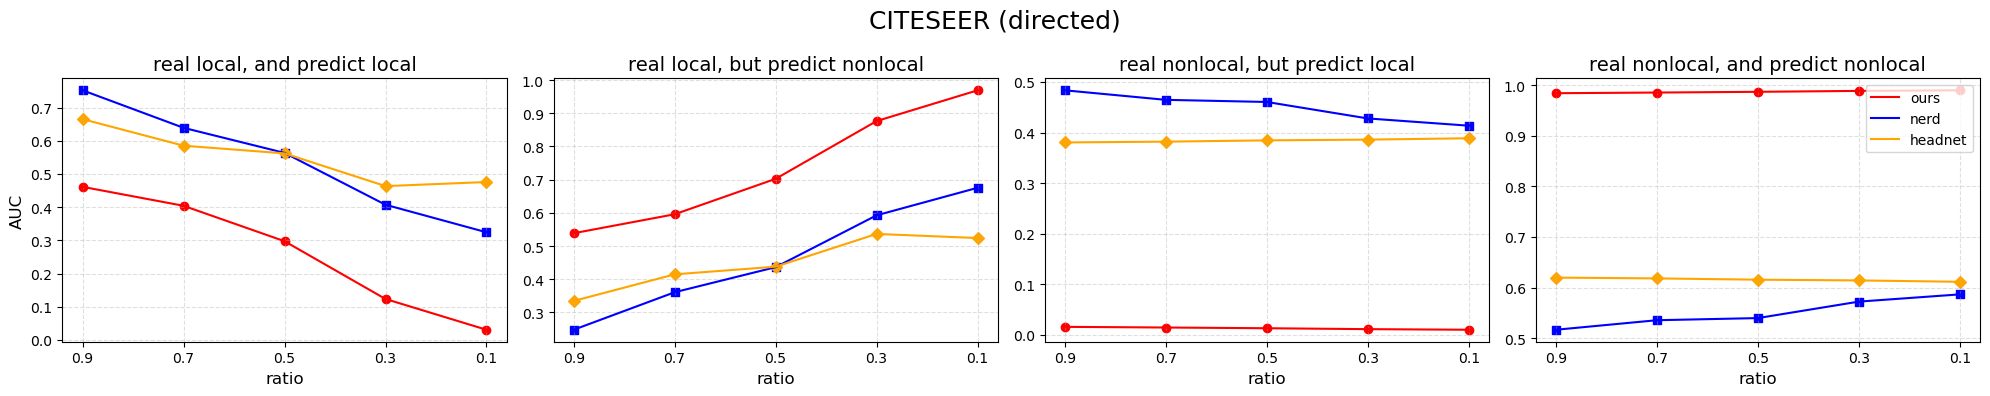

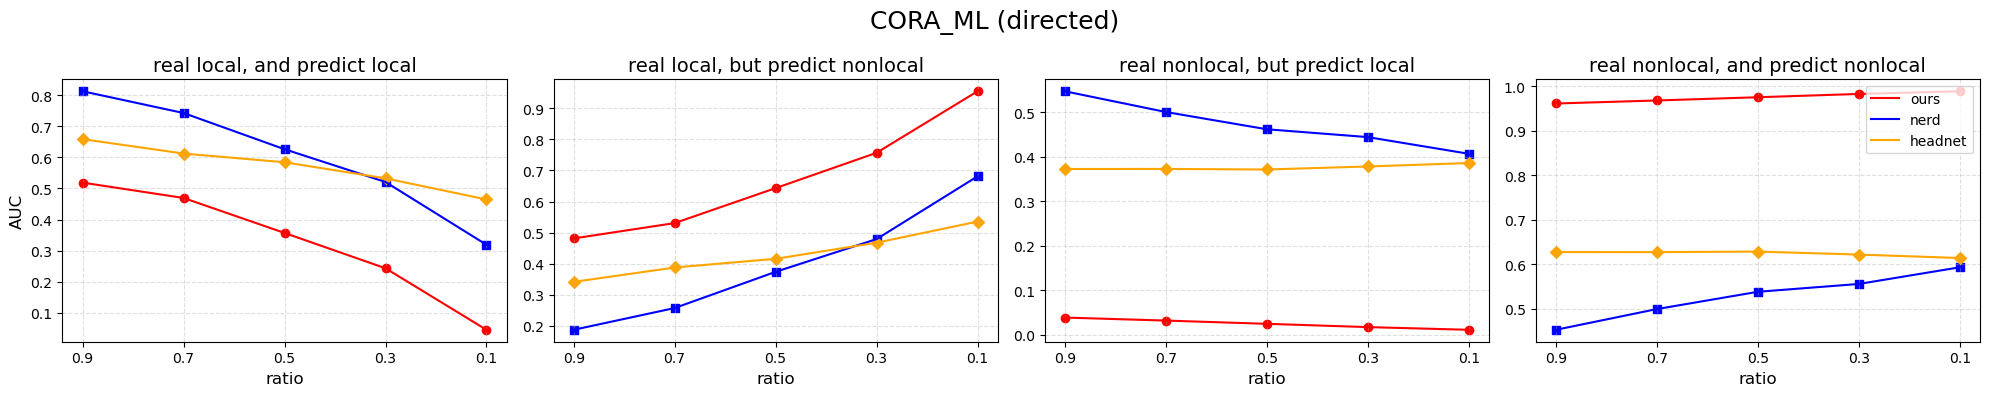

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_auc_panel(results, algorithms=('ours', 'nerd', 'headnet')):
    """
    results: dict[(dataset, ratio)] -> EvalOutput
    algorithms: 顺序对应不同颜色，默认 ours=红, node2vec=蓝
    """

    # 映射规则（图的位置 和 EvalOutput 字段名）
    metric_map = [
        ("real local, and predict local",     "TP_over_P"),  # TP / P
        ("real local, but predict nonlocal",  "FN_over_P"),  # FN / P
        ("real nonlocal, but predict local",  "FP_over_N"),  # FP / N
        ("real nonlocal, and predict nonlocal", "TN_over_N") # TN / N
    ]

    colors = {
        algorithms[0]: "red",
        algorithms[1]: "blue",
        algorithms[2]: "orange",
    }

    markers = {
        algorithms[0]: "o",
        algorithms[1]: "s",
        algorithms[2]: "D",
    }

    # 遍历每个 dataset 单独画图
    datasets = sorted(set(k[0] for k in results.keys()))
    for dataset in datasets:
        # 收集该 dataset 的所有 ratio（已假设相同 ratio 数量）
        ratios = sorted([k[1] for k in results.keys() if k[0] == dataset], reverse=True)

        fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
        fig.suptitle(dataset.upper() + " (directed)", fontsize=18)

        for ax, (title, field) in zip(axes, metric_map):
            for algo in algorithms:
                ys = []
                for ratio in ratios:
                    out = results[(dataset, ratio)]
                    auc_val = out.per_algorithm[algo].auc[f"AUC_{field}"]
                    ys.append(auc_val)

                ax.plot(ratios, ys, label=algo, color=colors[algo])
                ax.scatter(ratios, ys, color=colors[algo], marker=markers[algo])

            ax.set_title(title, fontsize=14)
            ax.set_xlabel("ratio", fontsize=12)
            ax.set_xticks(ratios)
            ax.invert_xaxis()  # 反转 x 轴，使 0.9 -> 0.1
            ax.grid(True, linestyle="--", alpha=0.4)

        axes[0].set_ylabel("AUC", fontsize=12)
        axes[-1].legend(loc="upper right")
        plt.tight_layout()
        plt.show()
plot_auc_panel(results)